In [1]:
import pandas as pd

In [2]:
pwd

'C:\\Users\\dell\\Machine Learning'

In [3]:
cd C:\Mock Test

C:\Mock Test


# Q1. Load the cleaned Bank Customer dataset. Identify the Type of ML Problem.  Select 'Churn' as target variable, and print the shape of X and y.

In [4]:
data = pd.read_csv("CleanedML.csv")

In [5]:
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42.0,2,0.00,1,1,1.0,101348.88,1
1,15647311,608,Spain,Female,41.0,1,83807.86,1,0,1.0,112542.58,0
2,15619304,502,France,Female,42.0,8,159660.80,3,1,0.0,113931.57,1
3,15701354,699,France,Female,39.0,1,0.00,2,0,0.0,93826.63,0
4,15737888,850,Spain,Female,43.0,2,125510.82,1,1,1.0,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39.0,5,0.00,2,1,0.0,96270.64,0
9996,15569892,516,India,Male,35.0,10,57369.61,1,1,0.0,101699.77,0
9997,15584532,709,France,Male,36.0,7,0.00,1,0,1.0,42085.58,1
9998,15682355,772,Germany,Male,42.0,3,75075.31,2,1,0.0,92888.52,1


In [6]:

# This is Supervised learning Classification SVM model

In [7]:
x = data.drop("churn", axis = 1)
y = data["churn"]

In [8]:
x.shape

(10000, 11)

In [9]:
y.shape

(10000,)

# Q2. Identify categorical columns, apply Encoding techniques (if necessary, perform Standard Scaling on numerical features. 

In [10]:
x.select_dtypes(include = "object").columns

Index(['country', 'gender'], dtype='object')

In [11]:
# So there is two categorical data country and gender

In [12]:
data["gender"].unique()

array(['Female', 'Male'], dtype=object)

In [13]:
data["country"].unique()

array(['France', 'Spain', 'India', 'Germany'], dtype=object)

In [14]:
# There no many unique vales so i prefered one hot encoding

In [15]:
x = pd.get_dummies(x, columns = ["country","gender"], drop_first = True)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
x = pd.DataFrame(scaler.fit_transform(x), columns = x.columns)

# Q.3.Plot churn distribution. Analyze the relationship between CreditScore, Age, and Balance with churn 

In [21]:
import matplotlib.pyplot as plt

In [22]:
import seaborn as sns

<Axes: xlabel='churn', ylabel='count'>

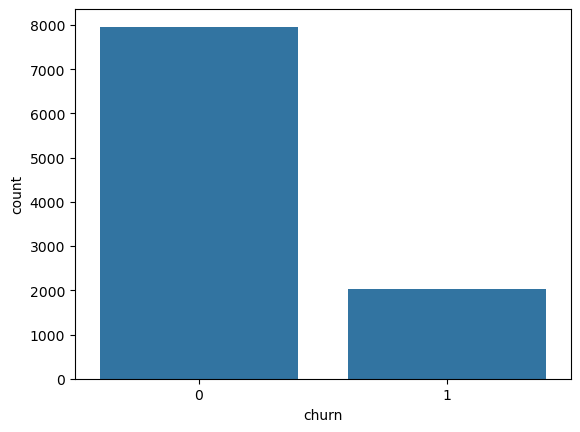

In [23]:
sns.countplot(x=y)

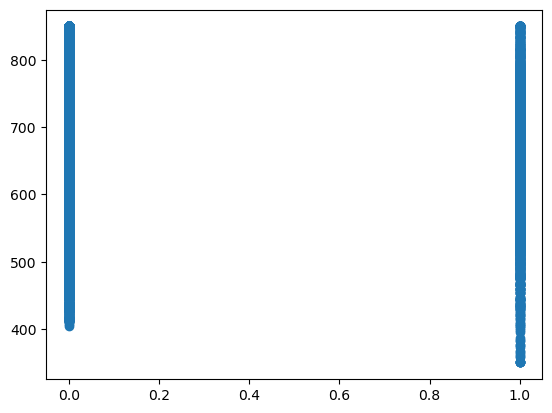

In [46]:
plt.scatter(data["churn"],data["credit_score"])

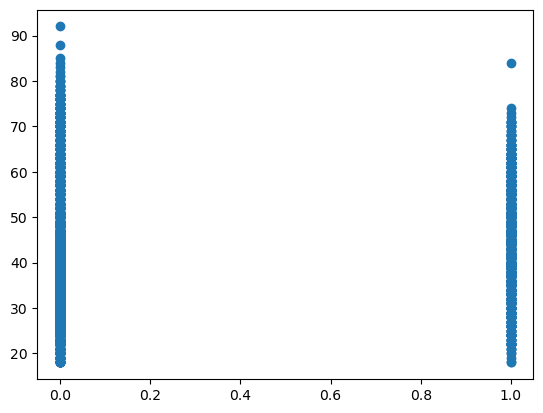

In [47]:
plt.scatter(data["churn"],data["age"])

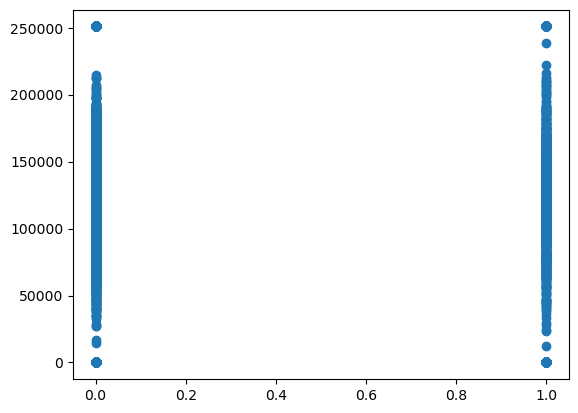

In [48]:
plt.scatter(data["churn"],data["balance"])

# Q.4 Split the dataset into training and testing sets. Train a SVM model and display accuracy Score, Confusion Matrix, Classification  Report.. 

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

In [26]:
from sklearn.svm import SVC

In [27]:
model = SVC()

In [28]:
model.fit(x_train,y_train)

SVC()

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
yp = model.predict(x_test)

In [31]:
accuracy_score(yp,y_test)

0.852

In [32]:
confusion_matrix(yp,y_test)

array([[1564,  253],
       [  43,  140]])

In [33]:
print(classification_report(yp,y_test))

              precision    recall  f1-score   support

           0       0.97      0.86      0.91      1817
           1       0.36      0.77      0.49       183

    accuracy                           0.85      2000
   macro avg       0.66      0.81      0.70      2000
weighted avg       0.92      0.85      0.87      2000



# Q5. Train a Random Forest Classifier on the same data and predict Churn,find - accuracy Score, Confusion Matrix, Classification  Report.

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
model1 = RandomForestClassifier()

In [36]:
model1.fit(x_train,y_train)

RandomForestClassifier()

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [42]:
yp1 = model1.predict(x_test)

In [43]:
accuracy_score(yp1,y_test)

0.8535

In [44]:
confusion_matrix(yp1,y_test)

array([[1537,  223],
       [  70,  170]])

In [45]:
print(classification_report(yp1,y_test))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      1760
           1       0.43      0.71      0.54       240

    accuracy                           0.85      2000
   macro avg       0.69      0.79      0.73      2000
weighted avg       0.89      0.85      0.87      2000

